**Install XGBoost**

In [ ]:
!pip install xgboost

**Import the required libraries**

In [ ]:
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

**Upload the feature dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_features.csv to master_features.csv


**Load the feature dataset**

In [ ]:
import pandas as pd

features = pd.read_csv("master_features.csv")

print(features.shape)
features.head()

(8622, 2055)


,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0


**Reload the dataset**

In [ ]:
features = pd.read_csv("master_features.csv")

**Separate predictors and target labels**

In [ ]:
X = features.drop("Label", axis=1)
y = features["Label"]

**Split the dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_test, X_external, y_test, y_external = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(X_external.shape)

(5173, 2054)
(1724, 2054)
(1725, 2054)


**Train the XGBoost model**

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


**Save the trained model**

In [ ]:
import joblib
import os

os.makedirs("/content/drive/MyDrive/Notebook5_Output", exist_ok=True)

joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


**Verify the saved model**

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl


**Predict class labels**

In [ ]:
# Predictions on test set
y_pred_test = xgb_model.predict(X_test)
y_prob_test = xgb_model.predict_proba(X_test)[:,1]

# Predictions on external validation set
y_pred_external = xgb_model.predict(X_external)
y_prob_external = xgb_model.predict_proba(X_external)[:,1]

**Evaluate the test dataset**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("===== Test Set =====")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))
print("F1-score :", f1_score(y_test, y_pred_test))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_test))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_test))

===== Test Set =====
Accuracy : 0.8097447795823666
Precision: 0.8281053952321205
Recall   : 0.7755581668625147
F1-score : 0.8009708737864077
ROC-AUC  : 0.8905970066884455

Confusion Matrix
[[736 137]
 [191 660]]


**Evaluate the external validation dataset**

In [ ]:
print("===== External Validation Set =====")
print("Accuracy :", accuracy_score(y_external, y_pred_external))
print("Precision:", precision_score(y_external, y_pred_external))
print("Recall   :", recall_score(y_external, y_pred_external))
print("F1-score :", f1_score(y_external, y_pred_external))
print("ROC-AUC  :", roc_auc_score(y_external, y_prob_external))

print("\nConfusion Matrix")
print(confusion_matrix(y_external, y_pred_external))

===== External Validation Set =====
Accuracy : 0.8150724637681159
Precision: 0.8253968253968254
Recall   : 0.7934272300469484
F1-score : 0.8090963494913226
ROC-AUC  : 0.8858470602154354

Confusion Matrix
[[730 143]
 [176 676]]


**Save the model again**

In [ ]:
import joblib
import os

os.makedirs("/content/drive/MyDrive/Notebook5_Output", exist_ok=True)

joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


**Confirm the saved model**

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"))

True


**Recreate the output folder**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook5_Output", exist_ok=True)

**Save the model to Google Drive**

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"
)

print("XGBoost model saved to Google Drive successfully!")

XGBoost model saved to Google Drive successfully!


**List saved files**

In [ ]:
!ls "/content/drive/MyDrive/Notebook5_Output"

XGBoost_model.pkl


**List Google Drive folders**

In [ ]:
!ls "/content/drive/MyDrive"

Notebook5_Output


**Plot ROC curves**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

<Figure size 600x500 with 0 Axes>

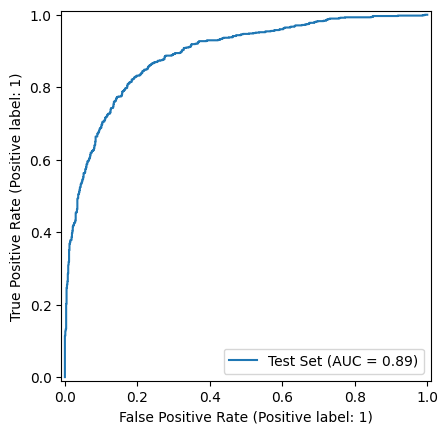

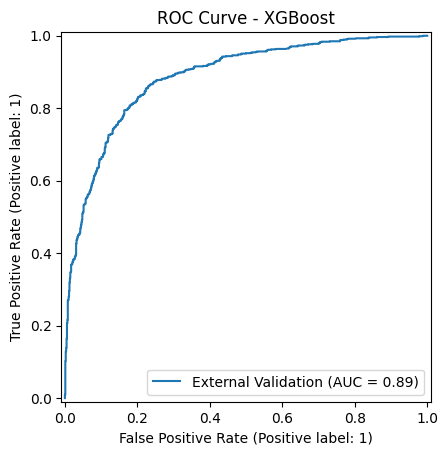

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_test, name="Test Set")
RocCurveDisplay.from_predictions(y_external, y_prob_external, name="External Validation")
plt.title("ROC Curve - XGBoost")
plt

**Plot the test confusion matrix**

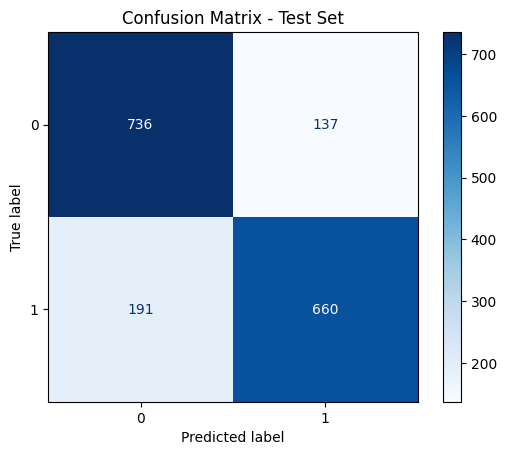

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

**Plot the external validation confusion matrix**

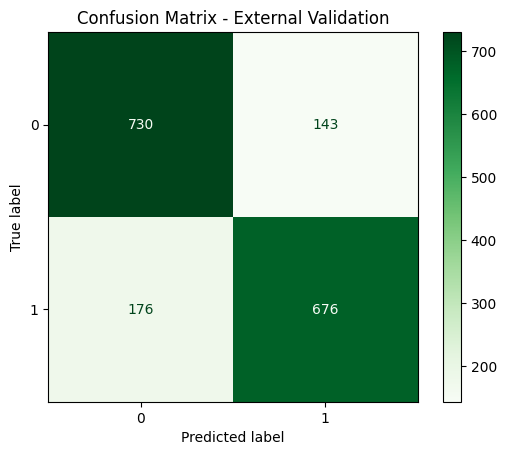

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_external, y_pred_external, cmap="Greens")
plt.title("Confusion Matrix - External Validation")
plt.show()

**Import feature importance module**

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

**Display saved output files**

In [ ]:
!ls "/content/drive/MyDrive/Notebook5_Output"

FeatureImportance_XGBoost.png  XGBoost_model.pkl


**Plot and save feature importance**

<Figure size 800x800 with 0 Axes>

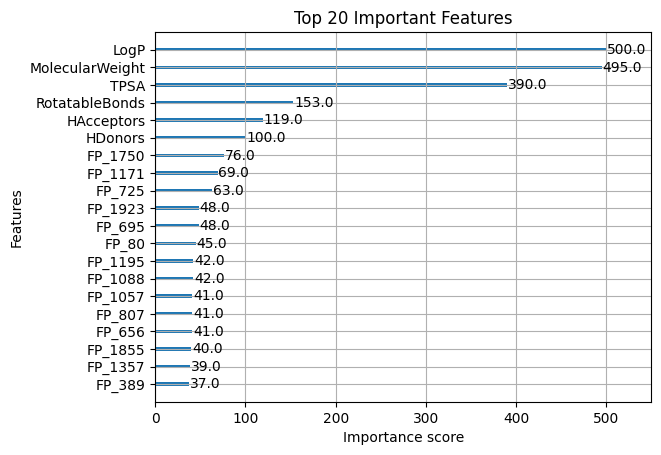

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,8))
plot_importance(xgb_model, max_num_features=20)
plt.title("Top 20 Important Features")

plt.savefig(
    "/content/drive/MyDrive/Notebook5_Output/FeatureImportance_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Retrain an XGBoost model**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

**Predict using the retrained model**

In [ ]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

**Calculate accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8178654292343387


**Generate the classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       873
           1       0.83      0.79      0.81       851

    accuracy                           0.82      1724
   macro avg       0.82      0.82      0.82      1724
weighted avg       0.82      0.82      0.82      1724



**Plot the confusion matrix**

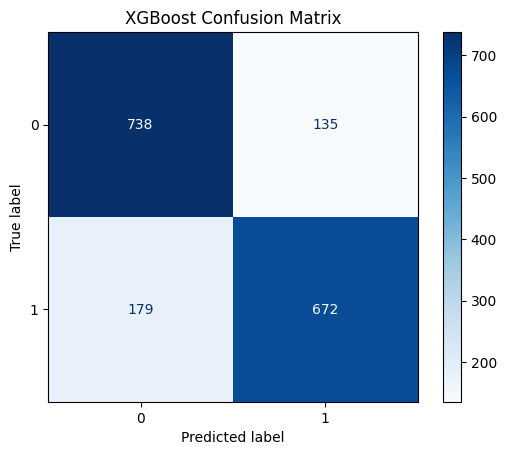

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

**Plot the ROC curve**

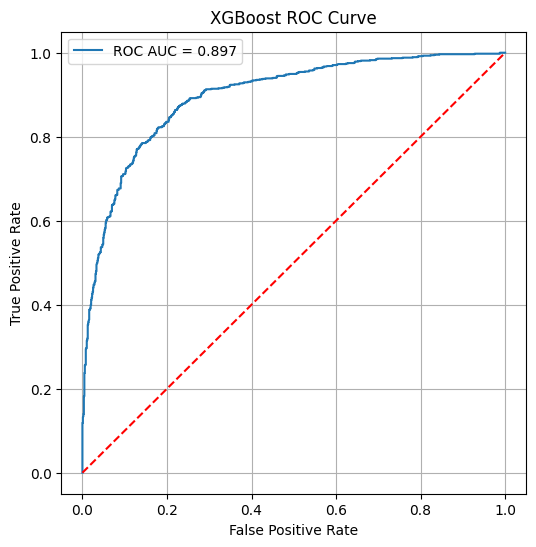

ROC-AUC: 0.8972141123642692


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC:", roc_auc)

**Plot the Precision–Recall curve**

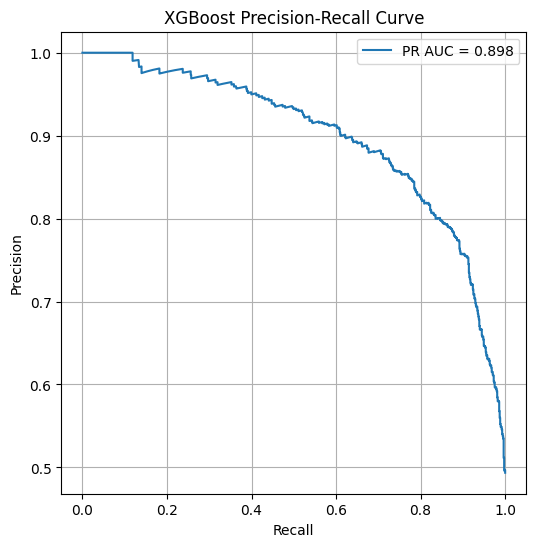

PR-AUC: 0.8978078153365643


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("PR-AUC:", pr_auc)